In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv('data.csv')
df.dtypes

id                           str
event_type                   str
latitude                 float64
longitude                float64
endlatitude              float64
endlongitude             float64
address                      str
end_address                  str
event_cause                  str
requires_road_closure       bool
start_datetime               str
end_datetime                 str
status                       str
authenticated                str
modified_datetime            str
map_file                 float64
direction                    str
description                  str
veh_type                     str
veh_no                       str
corridor                     str
priority                     str
cargo_material               str
reason_breakdown             str
age_of_truck             float64
created_date                 str
route_path                   str
client_id                  int64
created_by_id                str
last_modified_by_id          str
assigned_t

## 1. Core Identification & Metadata
id: A unique alphanumeric identifier for each logged traffic event or incident (e.g., FKID000000).<br>

status: The current operational status of the incident record (closed, active, or resolved).<br>

priority: The urgency or severity level assigned to the traffic incident (High or Low).<br>

authenticated: Indicates whether the incident has been verified and authenticated by the authority (yes or no).<br>

client_id: An internal identifier for the client platform or source system recording the data.<br>

## 2. Geographic & Location Information
latitude: The latitude coordinate where the incident started or was reported.<br>

longitude: The longitude coordinate where the incident started or was reported.<br>

address: The literal textual address or description of the location where the event took place.<br>

endlatitude: The latitude coordinate where a stretch-based event ends (often defaults to 0.0 if it's a point incident).<br>

endlongitude: The longitude coordinate where a stretch-based event ends (often defaults to 0.0 if it's a point incident).<br>

end_address: The textual description of the ending location for extended/stretch-based road incidents.<br>

direction: The direction of traffic flow affected (e.g., Northbound, Southbound).<br>

corridor: The major traffic corridor, highway, or radial road network affected (e.g., Tumkur Road, ORR East 1, or marked as Non-corridor).<br>

police_station: The local Bengaluru Traffic Police station jurisdiction responsible for managing the incident area (e.g., Peenya, HSR Layout, Wilson Garden).<br>

gba_identifier: Greater Bengaluru Area Corporation identifier, indicating which municipal corporation segment it falls into (e.g., Bengaluru Central Corporation).<br>

zone: The administrative traffic/civic zone managing the region (e.g., Central Zone 2, West Zone 1).<br>

junction: The specific traffic junction or landmark name closest to the event (e.g., UrvashiJunction).<br>

## 3. Event & Traffic Incident Details
event_type: Classification of whether the incident was unplanned (e.g., spontaneous breakdown/accident) or planned (e.g., pre-scheduled construction/public event).<br>

event_cause: The root cause of the traffic obstruction (e.g., vehicle_breakdown, pot_holes, construction, water_logging, accident, tree_fall).<br>

requires_road_closure: A boolean flag (True/False) representing whether the incident is severe enough to require shutting down the entire road.<br>

description: Detailed textual remarks or logs provided by the field officer (frequently containing a mix of English and Kannada describing the ground situation).<br>

route_path: Coordinate paths or spatial route details associated with the event (mostly empty or sparse).<br>

map_file: Placeholder column for supplementary map files/layers (fully empty in this dataset).<br>

comment: General remarks or additional system notes (fully empty in this dataset).<br>

meta_data: System-generated metadata properties (fully empty in this dataset).<br>

## 4. Vehicle Involvement Details (for Breakdowns/Accidents)
veh_type: The category of vehicle involved in the incident (e.g., lcv (Light Commercial Vehicle), heavy_vehicle, truck).<br>

veh_no: The anonymized registration/license plate number of the vehicle involved.<br>

cargo_material: The type of freight or material being carried by the vehicle (e.g., goods, BBMP lorry, Electric).<br>

reason_breakdown: The mechanical or operational reason behind the vehicle breakdown (e.g., clutch plate problem, Tyre burst, Starting problem).<br>

age_of_truck: The manufacturing year or approximate age of the involved vehicle.<br>

## 5. Timeline & Timestamps
start_datetime: The timestamp indicating exactly when the traffic event began or was reported.<br>

end_datetime: The timestamp indicating when the incident physically concluded.<br>

created_date: The date and time when this incident log entry was created in the database.<br>

modified_datetime: The timestamp showing when this incident log entry was last updated.<br>

resolved_datetime: The timestamp specifying when the problem was solved on the ground.<br>

closed_datetime: The timestamp specifying when the system ticket/log was formally marked as closed.<br>

## 6. Personnel & Assignment Details
kgid: Karnataka Government Insurance Department number—an anonymized unique official ID assigned to the specific traffic/police officer reporting or handling the event.<br>

created_by_id: Anonymized user ID of the person/operator who initially opened the ticket.<br>

last_modified_by_id: Anonymized user ID of the person who last edited the record.<br>

assigned_to_police_id: Anonymized ID of the specific field officer tasked to handle or clear the spot.<br>

closed_by_id: Anonymized ID of the user who officially closed out the incident log.<br>

resolved_by_id: Anonymized ID of the user who marked the status as resolved.<br>

citizen_accident_id: A reference ID connecting the log to a citizen-reported portal or emergency app.<br>

resolved_at_address: The verified address location where resolution steps were finalized.<br>

resolved_at_latitude: The exact latitude coordinate where the incident resolution was logged.<br>

resolved_at_longitude: The exact longitude coordinate where the incident resolution was logged.<br>

In [4]:
df.shape

(8173, 46)

In [5]:
df.isnull().sum()

id                          0
event_type                  0
latitude                    0
longitude                   0
endlatitude               169
endlongitude              169
address                     3
end_address              7486
event_cause                 0
requires_road_closure       0
start_datetime              0
end_datetime             7683
status                      0
authenticated               0
modified_datetime           0
map_file                 8173
direction                8130
description              1360
veh_type                 3286
veh_no                   3287
corridor                   20
priority                    2
cargo_material           7897
reason_breakdown         7897
age_of_truck             7897
created_date                0
route_path               8036
client_id                   0
created_by_id               2
last_modified_by_id         3
assigned_to_police_id    8045
citizen_accident_id      8045
comment                  8173
police_sta

In [6]:
print("Categorical columns:",df.select_dtypes(include=['object']).columns)
print("Numerical columns:",df.select_dtypes(include=['number']).columns)

Categorical columns: Index(['id', 'event_type', 'address', 'end_address', 'event_cause',
       'start_datetime', 'end_datetime', 'status', 'authenticated',
       'modified_datetime', 'direction', 'description', 'veh_type', 'veh_no',
       'corridor', 'priority', 'cargo_material', 'reason_breakdown',
       'created_date', 'route_path', 'created_by_id', 'last_modified_by_id',
       'assigned_to_police_id', 'citizen_accident_id', 'police_station',
       'kgid', 'resolved_at_address', 'closed_by_id', 'closed_datetime',
       'resolved_by_id', 'resolved_datetime', 'gba_identifier', 'zone',
       'junction'],
      dtype='str')
Numerical columns: Index(['latitude', 'longitude', 'endlatitude', 'endlongitude', 'map_file',
       'age_of_truck', 'client_id', 'comment', 'meta_data',
       'resolved_at_latitude', 'resolved_at_longitude'],
      dtype='str')


C:\Users\91947\AppData\Local\Temp\ipykernel_1924\3906224912.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print("Categorical columns:",df.select_dtypes(include=['object']).columns)


Now I have to figure out which variables are interrealted and the null  value columns are relelvant or not .

First we deal with numeric data

## End latitude and End longitude 

Can I put the null value as 0 that means may be it was a point incident that is y it is recorded as null 

## Map_file is removed as all the values were null 

In [7]:
df.drop('map_file',axis=1,inplace=True)

## Meta_data removed as it also has only null values 

In [8]:
df.drop('meta_data',axis=1,inplace=True)

## Comment removed as it has only null values and no significance in the  given scenario 

In [9]:
df.drop('comment',axis=1,inplace=True)

In [10]:
df.head()

,id,event_type,latitude,longitude,endlatitude,endlongitude,address,end_address,event_cause,requires_road_closure,...,resolved_at_address,resolved_at_latitude,resolved_at_longitude,closed_by_id,closed_datetime,resolved_by_id,resolved_datetime,gba_identifier,zone,junction
0,FKID000000,unplanned,13.040004,77.518099,0.000000,0.000000,"Mumbai Bengaluru Highway, Jalahalli Cross Junc...",NaN,vehicle_breakdown,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,FKID000001,unplanned,12.921876,77.645158,0.000000,0.000000,"19th Main Road, Heavie Halcyon, Agara, HSR Lay...",NaN,vehicle_breakdown,False,...,"19th Main Road, Heavie Halcyon, Agara, HSR Lay...",12.921876,77.645158,NaN,NaN,FKUSR00002,2024-01-30 04:17:46.828355+00,NaN,NaN,NaN
2,FKID000002,unplanned,12.955622,77.585708,0.000000,0.000000,"Lalbagh Main Road, Dr Sri Shantaveera Swami Ci...",NaN,others,False,...,NaN,NaN,NaN,FKUSR00003,2024-01-30 04:56:03.281509+00,NaN,NaN,Bengaluru Central Corporation,Central Zone 2,UrvashiJunction
3,FKID000003,unplanned,13.006147,77.579435,13.006239,77.579516,"Sankey Road, Bashyam Circle, Sadashiva Nagar, ...","Sankey Road, Palace Orchard Upper, Sadashiva N...",tree_fall,True,...,NaN,NaN,NaN,FKUSR00004,2024-03-14 07:42:05.54944+00,NaN,NaN,NaN,NaN,NaN
4,FKID000004,unplanned,12.953980,77.585233,0.000000,0.000000,"Lalbagh Fort Road, Lalbagh Main Gate Junction,...",NaN,vehicle_breakdown,False,...,NaN,NaN,NaN,FKUSR00003,2024-01-30 05:35:17.338283+00,NaN,NaN,NaN,NaN,LalbaghMainGateJunc


## Age of Truck 
Not relevant in this case so removed it .

In [11]:
df.drop('age_of_truck',axis=1,inplace=True)

## resolved_at_latitude, resolve_at_longitude 
We can say may that where there is null value for these column  may be it resolved in same latitude and longitude as it started so we can fill in that values as well but we can put iot as zero too I guess both will work .

In [12]:
df["resolved_at_longitude"].value_counts()
df["resolved_at_latitude"].value_counts()

resolved_at_latitude
12.921876    1
12.936847    1
12.954185    1
12.850980    1
12.955712    1
            ..
13.017779    1
13.017808    1
13.017901    1
12.951669    1
12.984603    1
Name: count, Length: 74, dtype: int64

## Categoric columns cleaning and data preparation 

## Adress has only 3 missing values 

In [13]:
df['address'].value_counts()

address
Outer Ring Road, Karthik Nagar, Marathahalli, Bengaluru, Karnataka. Pin-560037 (India)                                88
2nd Cross Road, MTB Area, Jayanagar, Bengaluru, Karnataka. Pin-560041 (India)                                         44
Sankey Road, RV Layout, Seshadripuram, Bengaluru, Karnataka. Pin-560020 (India)                                       36
MBT Road, Block 5 Stage 1, HBR Layout, Bengaluru, Karnataka. Pin-560043 (India)                                       35
Sankey Road, MD Nanjundaswamy Circle, Rajamahal Guttahalli, Bengaluru, Karnataka. Pin-560003 (India)                  34
                                                                                                                      ..
Service Road, ಕೆಂಪಾಪುರ, ಬೆಂಗಳೂರು ಉತ್ತರ ನಗರ ನಿಗಮ, Bengaluru, ಬೆಂಗಳೂರು ಉತ್ತರ, ಬೆಂಗಳೂರು ನಗರ, Karnataka, 560043, India     1
2nd Main Road, Bommanahalli Circle, Bommanahalli, Bengaluru, Karnataka. Pin-560068 (India)                             1
4th Cross Road, Jyothi N

## End_address has 7486 missing columns 
Now it can be two ways either is column is irrelavant 
or the values where is null it may end at same address where the evnet happened 

In [14]:
df["end_address"].value_counts()

end_address
Outer Ring Road, CQAE Staff Quarters, Yeshwanthpur, Bengaluru, Karnataka. Pin-560022 (India)                                           6
Varthuru Road, Deja View Homes, Nagavara Palya, CV Raman Nagar, Bengaluru, Karnataka. Pin-560093 (India)                               6
Kankanagar Main Road, Lawrence Layout, Nagavara, Bengaluru, Karnataka. Pin-560045 (India)                                              4
Hennur Main Road, Geddalahalli, Bengaluru, Karnataka. Pin-560077 (India)                                                               4
Cubbon Park Road, Krishna Rajendra Circle, Gandhi Nagar, Bengaluru, Karnataka. Pin-560001 (India)                                      4
                                                                                                                                      ..
Old Airport Road, Attimaramma Circle, Domlur, Bengaluru, Karnataka. Pin-560071 (India)                                                 1
BTS Main Road, NGO Colony, Wi

In [15]:
# 2. Clean up 'NULL' strings if they exist as text in your CSV
df['resolved_at_address'] = df['resolved_at_address'].replace(['NULL', 'null', ''], np.nan)

# 3. Fill missing 'resolved_at_address' using the starting 'address'
# .fillna() looks at 'resolved_at_address', and if it finds a missing value, 
# it grabs the value from the 'address' column for that same row.
df['resolved_at_address'] = df['resolved_at_address'].fillna(df['address'])

In [16]:
df['resolved_at_address'].isna().sum()

np.int64(3)

In [17]:
df["resolved_at_address"].value_counts()

resolved_at_address
Outer Ring Road, Karthik Nagar, Marathahalli, Bengaluru, Karnataka. Pin-560037 (India)                                88
2nd Cross Road, MTB Area, Jayanagar, Bengaluru, Karnataka. Pin-560041 (India)                                         44
Sankey Road, RV Layout, Seshadripuram, Bengaluru, Karnataka. Pin-560020 (India)                                       36
MBT Road, Block 5 Stage 1, HBR Layout, Bengaluru, Karnataka. Pin-560043 (India)                                       35
Sankey Road, MD Nanjundaswamy Circle, Rajamahal Guttahalli, Bengaluru, Karnataka. Pin-560003 (India)                  34
                                                                                                                      ..
Service Road, ಕೆಂಪಾಪುರ, ಬೆಂಗಳೂರು ಉತ್ತರ ನಗರ ನಿಗಮ, Bengaluru, ಬೆಂಗಳೂರು ಉತ್ತರ, ಬೆಂಗಳೂರು ನಗರ, Karnataka, 560043, India     1
2nd Main Road, Bommanahalli Circle, Bommanahalli, Bengaluru, Karnataka. Pin-560068 (India)                             1
4th Cross Ro

## End_address 
I dont get the point this column as we also have a column called resolved_at_address

In [18]:
row_index = 500

# 3. Get the two address values from that single row
end_addr = str(df.loc[row_index, 'end_address']).strip()
res_addr = str(df.loc[row_index, 'resolved_at_address']).strip()

# 4. Print the comparison clearly
print(f"--- Checking Row Index {row_index} ---")
print(f"End Address:      {end_addr}")
print(f"Resolved Address: {res_addr}")
print("-" * 30)

# Check if they are identical
if end_addr == res_addr:
    print("Result: They are the EXACT SAME!")
else:
    print("Result: They are DIFFERENT!")

--- Checking Row Index 500 ---
End Address:      nan
Resolved Address: Museum Road, Shoolay Circle, Nilsandra, Bengaluru, Karnataka. Pin-560025 (India)
------------------------------
Result: They are DIFFERENT!


Because most rows in your dataset are single-spot issues (like a pothole or a quick car breakdown), they don't have a natural stretching "end point." Therefore, it is safe to assume the problem ends exactly where it started.


In [19]:
df['end_address'] = df['end_address'].replace(['NULL', 'null', ''], np.nan)
df['address'] = df['address'].replace(['NULL', 'null', ''], np.nan)

# 3. Fill missing 'end_address' using the starting 'address'
df['end_address'] = df['end_address'].fillna(df['address'])

# 4. Backup safety check: If any row still remains missing (e.g., if both columns were completely empty)
df['end_address'] = df['end_address'].fillna('Unknown Location')

## End_datetime
I think it has no relation with the predictor variables

In [20]:
df["end_datetime"].value_counts()


end_datetime
2024-03-18 03:05:46+00    9
2024-03-03 20:05:46+00    5
2024-01-22 11:35:46+00    4
2024-02-19 07:05:46+00    3
2024-02-10 12:05:46+00    2
                         ..
2024-01-25 03:16:46+00    1
2024-01-25 04:13:46+00    1
2024-01-28 00:05:46+00    1
2024-01-28 02:05:46+00    1
2024-01-29 02:31:46+00    1
Name: count, Length: 459, dtype: int64

## Direction 
not sure what do . Forst thought was to remove then it came to mind that it can be useful for diversion prediction but u=it is 8k+ missing values so I am unable to think how to clean it 

In [21]:
df.drop('direction',axis=1,inplace=True)

## Description 
This is important but we have to find a way to clean it then form word cloud 

In [22]:
df["description"].value_counts()

description
Starting problem                                                                                                        80
starting problem                                                                                                        58
[PERSON]                                                                                                                42
Vehicle breakdown                                                                                                       29
Vehicle break down                                                                                                      28
                                                                                                                        ..
LCV is off road due starting problem [PERSON] to [LOCATION] right side of the road traffic is moving little bit slow     1
Bmtc bus off at vasantapura cross signal incoming side sir                                                               1
Bmtc

If the description is blank but we already know the event_cause (like vehicle_breakdown, accident, or tree_fall) and sometimes even the veh_type, we can automatically build a clean, standardized description sentence.

For example:

If event_cause is vehicle_breakdown and veh_type is lcv, we can generate: "lcv vehicle_breakdown reported"

If veh_type is missing too, we can fall back on a clean: "vehicle_breakdown reported"

In [23]:
df['description'] = df['description'].replace(['NULL', 'null', ''], np.nan)

# 2. Define a function to generate a description when it is missing
def create_default_description(row):
    # If a description already exists, leave it exactly as it is!
    if pd.notna(row['description']):
        return row['description']
    
    # Grab the cause and vehicle type to build a sentence
    cause = str(row['event_cause']).strip()
    veh = str(row['veh_type']).strip()
    
    # Scenario A: If both vehicle type and cause are available
    if pd.notna(row['veh_type']) and veh != 'NULL' and veh != '':
        return f"{veh} {cause} reported"
    
    # Scenario B: If only the cause is available
    else:
        return f"{cause} reported"

# 3. Apply the fix to the description column
df['description'] = df.apply(create_default_description, axis=1)

## Vehicle type 
very important factor I think for our prediction 
we cab fill thso values according to the keywords in description 

In [24]:
df['veh_type'].value_counts()

veh_type
bmtc_bus         1466
heavy_vehicle     965
lcv               678
others            449
private_bus       359
private_car       345
truck             276
ksrtc_bus         217
taxi               95
auto               37
Name: count, dtype: int64

In [25]:
df.drop('veh_no',axis=1,inplace=True)

Chnged vehicle type according to the description using previous data 
there may be a slight prob as we dont know wheter it is after analysing the description or not . But this solution can work

In [26]:
df['veh_type'] = df['veh_type'].replace(['NULL', 'null', ''], np.nan)

# Convert description log to lowercase for precise text matching
df['description_clean'] = df['description'].astype(str).str.lower()

# 2. Define mapping function matching your exact categories
def fill_vehicle_categories(row):
    # If the row already has a valid category from your list, keep it!
    if pd.notna(row['veh_type']):
        return row['veh_type']
    
    cause = str(row['event_cause']).lower()
    desc = row['description_clean']
    
    # Text mining the 'description' field using keywords for your specific categories
    if 'bmtc' in desc:
        return 'bmtc_bus'
    
    elif 'ksrtc' in desc:
        return 'ksrtc_bus'
    
    elif 'private bus' in desc or 'school bus' in desc or 'tourist bus' in desc:
        return 'private_bus'
    
    # Catch-all for general buses if not specified
    elif 'bus' in desc:
        return 'bmtc_bus' # Defaulting general buses to BMTC as it's the most common in Bengaluru
        
    elif 'truck' in desc or 'lorry' in desc:
        return 'truck'
        
    elif 'tipper' in desc or 'dumper' in desc or 'container' in desc or 'mixer' in desc:
        return 'heavy_vehicle'
        
    elif 'lcv' in desc or 'tempo' in desc or 'ace' in desc or 'pickup' in desc or 'mahindra' in desc:
        return 'lcv'
        
    elif 'taxi' in desc or 'ola' in desc or 'uber' in desc or 'cabs' in desc:
        return 'taxi'
        
    elif 'car' in desc or 'suv' in desc or 'jeep' in desc:
        return 'private_car'
        
    elif 'auto' in desc or 'rickshaw' in desc:
        return 'auto'
        
    # If the incident is an infrastructure or environmental issue, no vehicle is responsible
    non_veh_causes = ['pot_holes', 'water_logging', 'tree_fall', 'public_event', 'procession', 'construction', 'vip_movement', 'protest', 'debris']
    if cause in non_veh_causes:
        return 'others'
        
    # Fallback default for any breakdown without specific vehicle keywords
    return 'others'

# 3. Process the column
df['veh_type'] = df.apply(fill_vehicle_categories, axis=1)

In [27]:
df["veh_type"].isna().sum()

np.int64(0)

## vehicle number I think is not important according to what we are predicting 

## Corridor 

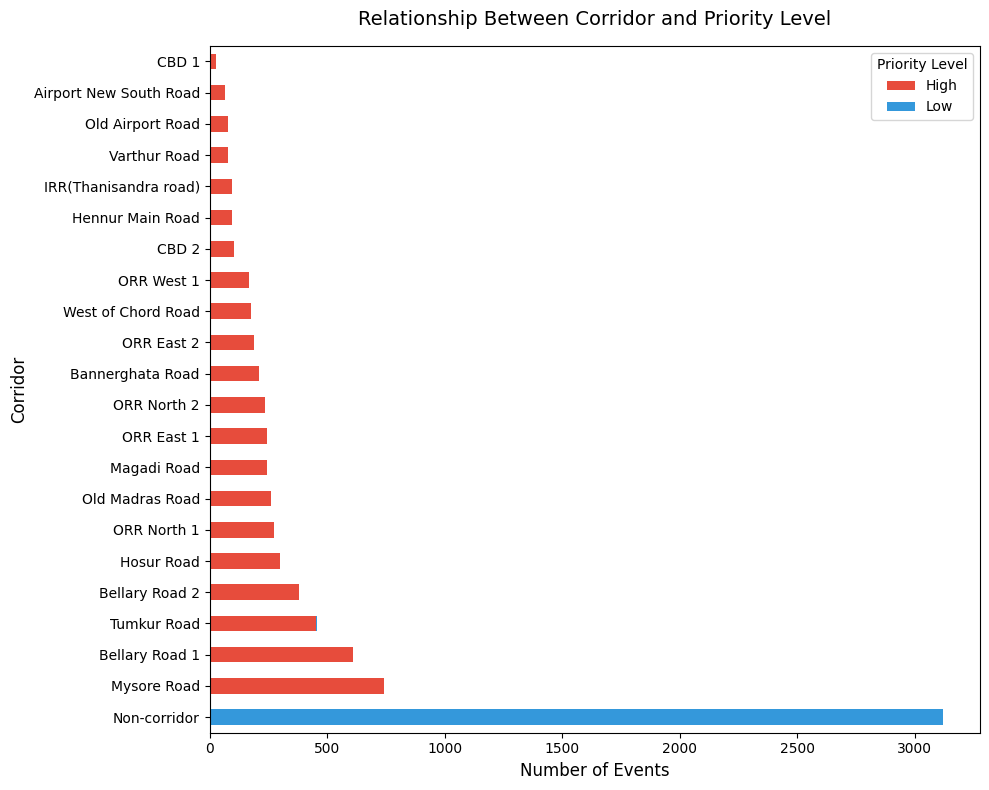

In [28]:
corridor_order = df['corridor'].value_counts().index

# ==========================================
# CHART 1: CORRIDOR VS PRIORITY RELATIONSHIP
# ==========================================
# Create a cross-tabulation table sorted by total corridor volume
priority_ct = pd.crosstab(df['corridor'], df['priority']).loc[corridor_order]

# Plot using subplots (avoiding .figure() to ensure layout stability)
fig, ax1 = plt.subplots(figsize=(10, 8))
priority_ct.plot(kind='barh', stacked=True, ax=ax1, color=['#e74c3c', '#3498db'])

ax1.set_title('Relationship Between Corridor and Priority Level', fontsize=14, pad=15)
ax1.set_xlabel('Number of Events', fontsize=12)
ax1.set_ylabel('Corridor', fontsize=12)
ax1.legend(title='Priority Level')
plt.tight_layout()

decided to fill the missing values with non corridor 

In [29]:
df['corridor'] = df['corridor'].fillna('Non-corridor')

## Cargo material 

In [30]:
df['cargo_material'].value_counts()

cargo_material
Goods            23
goods            20
Goods carried    18
goods carried    13
Yes              11
                 ..
Raggi             1
Food vehicle      1
Furniture         1
Plastic pipes     1
Gods              1
Name: count, Length: 138, dtype: int64

Replace the missing values with no goods . Considering missing  values as no goods carried .
Afterwards in the Ml part we will see its relation then we will encode it accordingly 

In [31]:
# 2. Clean up text 'NULL' or empty strings to actual Python missing values (NaN)
df['cargo_material'] = df['cargo_material'].replace(['NULL', 'null', ''], np.nan)

# 3. Fill all missing spaces in cargo_material with 'no goods'
df['cargo_material'] = df['cargo_material'].fillna('no goods')

## Reason for breakdown

In [32]:
df['reason_breakdown'].value_counts()

reason_breakdown
Starting problem         22
starting problem         11
Breakdown                 8
breakdown                 6
break down                5
                         ..
Fan belt problem          1
Under brige               1
Heavy vehicle             1
Due to  tyre puncture     1
Starting problam          1
Name: count, Length: 193, dtype: int64

Since reason_breakdown specifically tracks mechanical failures for vehicles, we can use a two-step cleaning process:

Identify Non-Vehicle Events: For rows caused by environment or infrastructure issues (like pot_holes, water_logging, tree_fall, or public_event), a mechanical breakdown reason does not exist. We should change these missing values to 'not_applicable'.

Handle Empty Vehicle Breakdowns: For rows where a vehicle did break down or get into an accident, but the officer did not specify the exact mechanical issue, we should change the missing values to 'unknown_breakdown'

In [33]:
df['reason_breakdown'] = df['reason_breakdown'].replace(['NULL', 'null', ''], np.nan)

# 2. Define a function to intelligently fill the missing data
def fill_breakdown_reasons(row):
    # If a reason is already listed, keep it!
    if pd.notna(row['reason_breakdown']):
        return row['reason_breakdown']
    
    cause = str(row['event_cause']).lower()
    
    # List of causes where a mechanical vehicle breakdown makes no sense
    non_veh_causes = ['pot_holes', 'water_logging', 'tree_fall', 'public_event', 'procession', 'construction', 'vip_movement', 'protest', 'debris']
    
    if cause in non_veh_causes:
        return 'not_applicable'
    
    # If it is an actual vehicle breakdown or accident but the reason is blank
    elif cause in ['vehicle_breakdown', 'accident']:
        return 'unknown_breakdown'
        
    # Standard fallback default
    return 'unknown_breakdown'

# 3. Apply the function to fill the column gaps
df['reason_breakdown'] = df.apply(fill_breakdown_reasons, axis=1)

## Created by id and last modified by id  
We can replace the null values by unknown user 

In [34]:
df['created_by_id'] = df['created_by_id'].replace(['NULL', 'null', ''], np.nan)
df['last_modified_by_id'] = df['last_modified_by_id'].replace(['NULL', 'null', ''], np.nan)

# 3. Fill the missing values with a uniform system identifier string
df['created_by_id'] = df['created_by_id'].fillna('unknown user').astype(str)
df['last_modified_by_id'] = df['last_modified_by_id'].fillna('unknown user').astype(str)

## assigned to police by id 
I think we can remove this column as police station we know so we dont need the column id .

In [35]:
df['assigned_to_police_id'].value_counts()

assigned_to_police_id
FKUSR01441    52
FKUSR00292     4
FKUSR01429     3
FKUSR00599     3
FKUSR01540     3
              ..
FKUSR01872     1
FKUSR00855     1
FKUSR01311     1
FKUSR00120     1
FKUSR01941     1
Name: count, Length: 62, dtype: int64

In [36]:
df.drop('assigned_to_police_id',axis=1,inplace=True)

## Police station 

In [37]:
df['police_station'].value_counts()

police_station
Yelahanka                 377
HAL Old Airport           361
Sadashivanagar            302
Byatarayanapura           297
Halasuru Gate             297
Yeshwanthpura             280
Hennuru                   276
Kodigehalli               272
Banaswadi                 245
K.R. Pura                 228
Kamakshipalya             224
No Police Station         219
Cubbon Park               212
Jalahalli                 197
Chamarajpet               192
High ground               185
Madiwala                  184
Whitefield                181
Peenya                    178
Jayanagara                178
Ashok Nagar               171
Magadi Road               142
Hebbala                   135
Jnanabharathi             134
Jeevanbheemanagar         127
R.T. Nagar                127
J.P. Nagar                124
Electronic City           124
Sheshadripuram            123
Mahadevapura              120
Adugodi                   120
Halasur                   118
Chikkabanavara           

## Citizen _accident_id
Not related column 

In [38]:
df.drop('citizen_accident_id',axis=1,inplace=True)

## Kgid ->Karnataka Government Insurance Department 
we can remove it bcz it just acts as an id nothing else 

In [39]:
df.drop('kgid',axis=1,inplace=True)

## resolved_by_id 
it can be remove as it is just an id 

In [40]:
df.drop('resolved_by_id',axis=1,inplace=True)

## Gba_identifier 
In this we are filling the missing values by seeing the police station name 

In [41]:
mapping = (
    df[df['gba_identifier'].notna()]
    .groupby('police_station')['gba_identifier']
    .agg(lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else np.nan)
)

mask = df['gba_identifier'].isna()

df.loc[mask, 'gba_identifier'] = (
    df.loc[mask, 'police_station']
      .map(mapping)
)

In [42]:
df["gba_identifier"].isna().sum()

np.int64(37)

In [43]:
stations_missing = (
    df[df['gba_identifier'].isna()]['police_station']
    .unique()
)

for station in stations_missing:
    print(station)

Devanahalli Airport


We assume those 37 police station has same gba_identifier 

In [44]:
df['gba_identifier'] = (
    df['gba_identifier']
    .fillna('Devanahalli_Airport_Zone')
)

## Zone 
this also we are filling by police station name.doubt regarding how to fill the remaining 37 values 

In [45]:
zone_map = (
    df[df['zone'].notna()]
    .groupby('police_station')['zone']
    .agg(lambda x: x.mode().iloc[0])
)

mask = df['zone'].isna()

df.loc[mask, 'zone'] = (
    df.loc[mask, 'police_station']
      .map(zone_map)
)

In [46]:
df['zone'].isna().sum()

np.int64(37)

## end latitude and end longitude

In [47]:
# Fill missing end coordinates with start coordinates

df['endlatitude'] = df['endlatitude'].fillna(df['latitude'])
df['endlongitude'] = df['endlongitude'].fillna(df['longitude'])



## Junction 


In [48]:
df['junction'] = df['junction'].fillna('Unknown_Junction')


## Route path is not an important factor in this case for the analysis so we can remove the column 


In [49]:
df.drop('route_path',axis=1,inplace=True)

# end_datetime 


In [50]:
df[['start_datetime', 'end_datetime', 'closed_datetime']].sample(20)
df[df['end_datetime'].isna()][
    ['start_datetime', 'closed_datetime']
].head(20)

,start_datetime,closed_datetime
0,2024-03-07 17:01:48.111+00,NaN
1,2024-01-30 04:07:24.173+00,NaN
2,2023-11-11 06:18:03.343+00,2024-01-30 04:56:03.281509+00
3,2024-03-07 17:56:55.061+00,2024-03-14 07:42:05.54944+00
4,2024-01-30 04:56:32.348+00,2024-01-30 05:35:17.338283+00
5,2023-11-28 03:07:27.292421+00,NaN
6,2024-01-30 07:26:26.739+00,NaN
7,2024-01-30 06:05:59.339+00,2024-02-16 01:28:18.330429+00
9,2024-01-30 05:25:50.078+00,NaN
10,2024-03-07 18:01:40.182+00,2024-03-14 05:49:58.160945+00


The missing end_datetime values are not all the same type of missing
Group A: Missing end_datetime but closed_datetime exists(replaced by closed_datetime)
Group B: Missing end_datetime AND missing closed_datetime(replaced by start_datetime)

In [51]:
df['end_datetime'] = df['end_datetime'].fillna(df['closed_datetime'])
df['end_datetime'] = df['end_datetime'].fillna(df['start_datetime'])
print(df['end_datetime'].isna().sum())

0


In [52]:
df['zone'] = df['zone'].fillna('Devanahalli_Airport_Zone')

## Resolved at latitude and Longitude 
For null value we consider the event is resolved in the same place

In [53]:
df['resolved_at_latitude'] = (
    df['resolved_at_latitude']
    .fillna(df['latitude'])
)

df['resolved_at_longitude'] = (
    df['resolved_at_longitude']
    .fillna(df['longitude'])
)

In [54]:
df = df.dropna(subset=['address', 'priority'])

## Closed datetime 
We consider that the values where it is null it is equal to the end_datetime

In [55]:
df['closed_datetime'] = (
    df['closed_datetime']
    .fillna(df['end_datetime'])
)

In [56]:
df.drop('resolved_datetime',axis=1,inplace=True)


In [57]:
df.isnull().sum()

id                          0
event_type                  0
latitude                    0
longitude                   0
endlatitude                 0
endlongitude                0
address                     0
end_address                 0
event_cause                 0
requires_road_closure       0
start_datetime              0
end_datetime                0
status                      0
authenticated               0
modified_datetime           0
description                 0
veh_type                    0
corridor                    0
priority                    0
cargo_material              0
reason_breakdown            0
created_date                0
client_id                   0
created_by_id               0
last_modified_by_id         0
police_station              0
resolved_at_address         0
resolved_at_latitude        0
resolved_at_longitude       0
closed_by_id             5028
closed_datetime             0
gba_identifier              0
zone                        0
junction  

In [58]:
df.shape


(8168, 35)

## saving the cleaned data

In [59]:
df.to_csv("Cleaned_Dataset.csv", index=True)